# W + Charm Analysis:

This analysis is done using `Coffea` (version 2024.10.0) and `Awkward Arrays`. This study will focus on the event selection of W+c Events. This analysis will focus on the selection of W+c Events. The dataset used for this is: [W1JetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v1/NANOAODSIM](https://opendata.cern.ch/record/69545).

In [74]:
import hist as h
import dask
import awkward as ak
import hist.dask as dhist
import dask_awkward as dak
import uproot
import numpy as np
import mplhep as mh
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import matplotlib.pyplot as plt

NanoAODSchema.warn_missing_crossrefs = False

In [75]:
events = NanoEventsFactory.from_root(
    {"../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root": "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

dask.awkward<from-uproot, npartitions=1>

In [76]:
# Defining the style for plots (CMS Style)
from mplhep.plot import AnchoredText


plt.style.use(mh.style.CMS)
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Histogram Function:
def make_hist(data, nBins, lo, hi, xLabel, yLabel, label, fname=None, logy=False):
    histogram = dhist.Hist(h.axis.Regular(nBins, lo, hi))
    fig, ax = plt.subplots(1 ,1, figsize=(6,4))
    histogram.fill(data)
    # histogram.compute().plot(ax=ax , yerr=False, label=label)  
    mh.histplot(histogram.compute(), ax=ax, label=label, yerr=False, histtype="step") 
    mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
    n_entries = len(data.compute())
    mean_val = np.mean(data.compute())
    std_val = np.std(data.compute())

    stat_text = (f"Entries: {n_entries}\n"
                 f"Mean:    {mean_val:.2f}\n"
                 f"Std Dev: {std_val:.2f}")
    at = AnchoredText(stat_text, prop=dict(size=10), frameon=True, loc='center right')
    ax.add_artist(at)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    ax.legend(loc='upper left')
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    ax.legend()
    if logy:
        ax.set_yscale("log")
    if fname:
        plt.savefig(fname)
    plt.show()


## Event Selection:

Approach to Event Selection:

- Select events with at least two muons.
- Make selection of $\bf{W}$ from $W \rightarrow \mu + \nu$ process. Make selection of $\mu$ that are associated with a $W$. The $\mu$ are selected on the basis:
    1. $p_{T}$ > 35 GeV (high-$p_{T}$).
    2. $\eta$ < 2.4.
    3. `pfRelIso04_all` < 0.15 (isolated).
    4. `tightId` == True/1.
- This gives our W candidates.
- Make selection of $c$ from $H_{c} \rightarrow \mu + X$ process. Make selection of non-isolated, soft muons and then make selections of jets associated with these soft muons.
    1. $p_{T}$ < 20 GeV. (soft-muons)
    2. $\eta$ < 2.4.
    3. `pfRelIso04_all` > 0.2 (non-isolated).
    4. `tightId` == True/1.
- Then we match the muons with the jets (using `JetIdx`).
- This gives are c-Jet candidates.

In [77]:
# Events with atleast 2 muons:
nMu = dak.num(events.Muon.pt)
EventSelection = (nMu >= 2)
events = events[EventSelection]

# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet

In [78]:
# W -> Mu Nu Channel Selection:
W_MuMask = (
    (Muon.pt > 30) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == True) &
    (Muon.pfRelIso04_all < 0.15)
    )
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]
# Select events with exactly one W muon:
nMu = dak.num(W_Muons.pt)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

In [79]:
# C-jet -> Mu X Channel Selection:
cMuPassCuts = (
    (Muon.pt < 20) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) &
    (Muon.tightId == 1)
)
soft_muon = Muon[cMuPassCuts]

# Require the muon be matched to a jet (jetIdx >= 0)
soft_muon_injet = soft_muon[soft_muon.jetIdx >= 0]

# Get the matched jet for each selected muon
matched_jet = Jet[soft_muon_injet.jetIdx]

# Apply jet cuts on the *matched jets*
Jet_PassCuts = (
    (matched_jet.pt > 30) & 
    (abs(matched_jet.eta) < 2.4)
)

# Keep only muons whose matched jet passes jet cuts
soft_muon_in_goodjet = soft_muon_injet[Jet_PassCuts]
c_Jets = matched_jet[Jet_PassCuts]
nC_Jets = dak.num(c_Jets.pt)
# Select events with atleast one c-jet:
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

Selecting events that has both $W$ and $c$-jets and then plotting there observables.  

In [80]:
Wc_Events = events[evt_has_1WMu & evt_has_cJet]

In [81]:
Wc_Muons = Wc_Events.Muon
Wc_Jets = Wc_Events.Jet

nWcMuons = dak.num(Wc_Muons.pt)
nWcJets = dak.num(Wc_Jets.pt)

## OS and SS events:

OS pairs: 96
SS pairs: 26


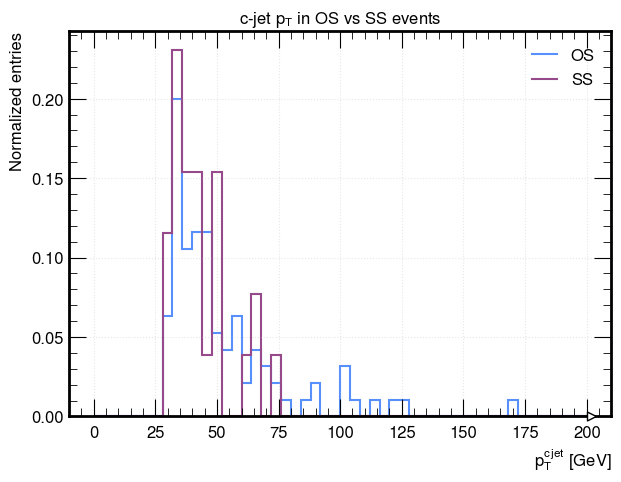

In [83]:
# OS/SS classification and overlay plot of c-jet pT
import numpy as np
import matplotlib.pyplot as plt
import dask_awkward as dak
import hist

# Work on the W+c selected sample
events_wc = Wc_Events
Muon_wc = events_wc.Muon
Jet_wc = events_wc.Jet
MET_wc = events_wc.MET

# Re-build the W-muon selection on the W+c sample (keeps shapes consistent)
W_MuMask_wc = (
    (Muon_wc.pt > 30) &
    (abs(Muon_wc.eta) < 2.4) &
    (Muon_wc.tightId == True) &
    (Muon_wc.pfRelIso04_all < 0.15)
    )
Mt_wc = np.sqrt(2 * Muon_wc.pt * MET_wc.pt * (1 - np.cos(Muon_wc.phi - MET_wc.phi)))
Mt_Cut_wc = (Mt_wc > 50)
W_MuMask_wc = W_MuMask_wc & Mt_Cut_wc
W_muons_wc = Muon_wc[W_MuMask_wc]

# Exactly one W-muon per event
n_WMu_wc = dak.num(W_muons_wc.pt)
evt_has_1WMu_wc = (n_WMu_wc == 1)
W_muons_wc = W_muons_wc[evt_has_1WMu_wc]
events_wc = events_wc[evt_has_1WMu_wc]
Muon_wc = events_wc.Muon
Jet_wc = events_wc.Jet

# Re-build the c(soft)-muon + matched-jet selection on the same event subset
cMuMask_wc = (
    (Muon_wc.pt < 20) &
    (abs(Muon_wc.eta) < 2.4) &
    (Muon_wc.pfRelIso04_all > 0.2) &
    (Muon_wc.tightId == 1)
    )
soft_mu_wc = Muon_wc[cMuMask_wc]
soft_mu_wc = soft_mu_wc[soft_mu_wc.jetIdx >= 0]
matched_jet_wc = Jet_wc[soft_mu_wc.jetIdx]
Jet_PassCuts_wc = (
    (matched_jet_wc.pt > 30) &
    (abs(matched_jet_wc.eta) < 2.4)
    )
soft_mu_wc = soft_mu_wc[Jet_PassCuts_wc]
cJets_wc = matched_jet_wc[Jet_PassCuts_wc]

# OS/SS defined by the sign of (q_W * q_softmu) per c-jet candidate
WMuon_Charge = W_muons_wc.charge[:, 0]  # scalar per event
SoftMuon_Charge = soft_mu_wc.charge
charge_prod = WMuon_Charge * SoftMuon_Charge

OS_pair = (charge_prod < 0)
SS_pair = (charge_prod > 0)

cjet_pt_OS = dak.flatten(cJets_wc.pt[OS_pair])
cjet_pt_SS = dak.flatten(cJets_wc.pt[SS_pair])

nOS = int(dak.sum(OS_pair).compute())
nSS = int(dak.sum(SS_pair).compute())
print(f"OS pairs: {nOS}")
print(f"SS pairs: {nSS}")

# Histogram + overlay plot
axis_pt = hist.axis.Regular(50, 0, 200, name="pt", label=r"$p_{T}^{c\,\mathrm{jet}}$ [GeV]")
hist_OS = hist.dask.Hist(axis_pt)
hist_SS = hist.dask.Hist(axis_pt)
hist_OS.fill(pt=cjet_pt_OS)
hist_SS.fill(pt=cjet_pt_SS)
hOS = hist_OS.compute()
hSS = hist_SS.compute()

normalize = True  # set False for absolute counts
if normalize:
    if hOS.values().sum() > 0:
        hOS = hOS / hOS.values().sum()
    if hSS.values().sum() > 0:
        hSS = hSS / hSS.values().sum()

fig, ax = plt.subplots(figsize=(7, 5))
hOS.plot1d(ax=ax, label="OS", color="C0")
hSS.plot1d(ax=ax, label="SS", color="C3")
ax.set_title("c-jet $p_T$ in OS vs SS events")
ax.set_ylabel("Normalized entries" if normalize else "Entries")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

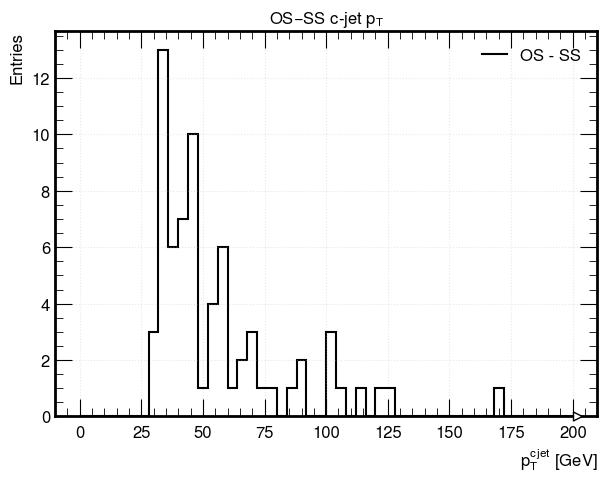

In [84]:
# OS - SS subtraction (c-jet pT)
import matplotlib.pyplot as plt

# Use unnormalized counts for OS-SS by default
hist_OS_counts = hist.dask.Hist(axis_pt)
hist_SS_counts = hist.dask.Hist(axis_pt)
hist_OS_counts.fill(pt=cjet_pt_OS)
hist_SS_counts.fill(pt=cjet_pt_SS)
hOS_counts = hist_OS_counts.compute()
hSS_counts = hist_SS_counts.compute()

hDiff = hOS_counts - hSS_counts

fig, ax = plt.subplots(figsize=(7, 5))
hDiff.plot1d(ax=ax, label="OS - SS", color="k")
ax.axhline(0.0, color="0.5", lw=1)
ax.set_title(r"OS$-$SS c-jet $p_T$")
ax.set_ylabel("Entries")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()